In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = 'course_lead_scoring.csv'

In [3]:
df = pd.read_csv(data)
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [4]:
categorical = ['lead_source', 'industry', 'employment_status', 'location']
numerical = ['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']

df[categorical] = df[categorical].fillna('NA')
df[numerical] = df[numerical].fillna(0.0)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold

In [6]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val =df_val.reset_index(drop=True)
df_test= df_test.reset_index(drop=True)

y_train = df_train.converted
y_val = df_val.converted
y_test = df_test.converted

del df_train['converted']
del df_val['converted']
del df_test['converted']

In [9]:
for col in numerical:
    auc = roc_auc_score(y_train, df_train[col])
    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[col])
    print(f'{col}: {auc:.4f}')

number_of_courses_viewed: 0.7636
annual_income: 0.5520
interaction_count: 0.7383
lead_score: 0.6145


In [10]:
train_dicts = df_train[categorical + numerical].to_dict(orient='records')
val_dicts = df_val[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict_proba(X_val)[:, 1]

val_auc = roc_auc_score(y_val, y_pred)

round(val_auc, 3)

0.817

In [11]:
scores = []
thresholds = np.linspace(0, 1, 101)

actual_positive = (y_val == 1)
actual_negative = (y_val == 0)

for t in thresholds:    
    predict_positive = (y_pred >= 0.5)
    predict_negative = (y_pred < 0.5)
    
    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()
    
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    scores.append((t, tp, fp, tn, fn, recall, precision))

In [12]:
df_scores = pd.DataFrame(scores, columns=['threshold', 'true_positive', 'false_positive', 'true_negative', 'false_negative', 'recall', 'precision'])

df_scores[::10]

,threshold,true_positive,false_positive,true_negative,false_negative,recall,precision
0,0.0,164,81,41,7,0.669388,0.959064
10,0.1,164,81,41,7,0.669388,0.959064
20,0.2,164,81,41,7,0.669388,0.959064
30,0.3,164,81,41,7,0.669388,0.959064
40,0.4,164,81,41,7,0.669388,0.959064
50,0.5,164,81,41,7,0.669388,0.959064
60,0.6,164,81,41,7,0.669388,0.959064
70,0.7,164,81,41,7,0.669388,0.959064
80,0.8,164,81,41,7,0.669388,0.959064
90,0.9,164,81,41,7,0.669388,0.959064


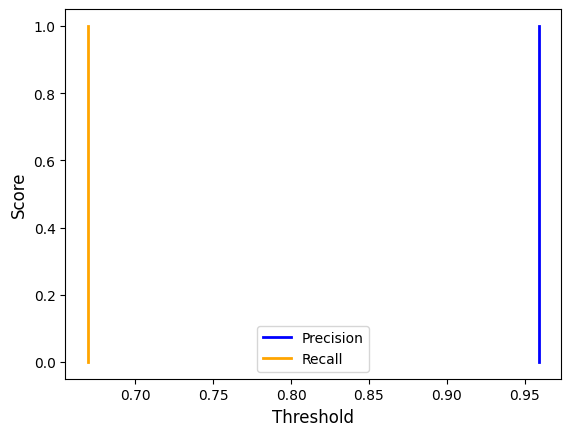

In [14]:
plt.plot(df_scores.precision, df_scores.threshold, label='Precision', color='blue', linewidth=2)
plt.plot(df_scores.recall, df_scores.threshold, label='Recall', color='orange', linewidth=2)

plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)

plt.legend()